# CSoT'26 - ML in Astronomy - Week 3 . Part 2: Evaluation and Interpretation (Starter)

**Goal:** Evaluate the CNN honestly. Track train-vs-validation loss, report a **test accuracy** that beats the Week-2 baseline, build a **confusion matrix** you can read astrophysically, and **save** the trained weights.

**Before you begin:**
1. Switch this notebook to a **GPU runtime** (`Runtime -> Change runtime type -> GPU`).
2. Read [`05-evaluation-and-overfitting.md`](../05-evaluation-and-overfitting.md), [`06-confusion-matrix-and-metrics.md`](../06-confusion-matrix-and-metrics.md), and [`07-saving-and-loading-models.md`](../07-saving-and-loading-models.md).

Replace each `TODO`. **Do not** open the solution until you've genuinely attempted every TODO.

## Step 0 - Data + model

Re-create the Week-1 `DataLoader`s and your `GalaxyCNN` (paste both from Part 1). You can either re-train here, or load Part 1's `galaxy_model.pth`. After this section you need: `train_loader`, `val_loader`, `test_loader`, `test_ds`, `num_classes`, `model`, `criterion`, `optimizer`.

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [36]:
import math
import random
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [37]:

import json

KAGGLE_USERNAME = "mandiraaich"
KAGGLE_KEY = "KGAT_da75e819847ce5948097dd89b3146c55"

kaggle_creds = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_KEY
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)

print("kaggle.json created successfully!")
!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets list -s galaxy-zoo | head

!kaggle datasets download \
    -d jaimetrickz/galaxy-zoo-2-images \
    --path /content/

print("Download complete.")
# Unzip the images
import zipfile

ZIP_PATH = "/content/galaxy-zoo-2-images.zip"
EXTRACT_TO = "/content/galaxy_raw"

if not os.path.exists(EXTRACT_TO):
    print("Extracting... (this may take a few minutes)")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_TO)
    print("Extraction complete.")
else:
    print("Already extracted.")

# Peek at the directory structure
for root, dirs, files_in_dir in os.walk(EXTRACT_TO):
    level = root.replace(EXTRACT_TO, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 1:
        sub_indent = '  ' * (level + 1)
        for f in files_in_dir[:5]:
            print(f"{sub_indent}{f}")
        if len(files_in_dir) > 5:
            print(f"{sub_indent}... and {len(files_in_dir)-5} more files")
    break  # only top level


kaggle.json created successfully!
ref                                       title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
jaimetrickz/galaxy-zoo-2-images           Galaxy Zoo 2: Images                           3281862708  2021-01-26 16:25:27.667000          10095         34  0.9411765        
robertmifsud/resized-reduced-gz2-images   Resized and Reduced Galaxy Zoo 2 Images        1934213890  2023-05-25 23:12:04.167000            701          6  0.8235294        
anjosut/galaxy-zoo-classification         Galaxy Zoo classification                       397550426  2023-04-08 04:28:53.070000            640          3  0.3529412        
zhuangjw/galaxy-zoo-cleaned               galaxy_zoo_cleaned                             2352353415  

In [38]:
# Download the Hart et al. 2016 morphology catalogue
import os

LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"
LABELS_PATH = "/content/galaxy_raw/gz2_hart16.csv.gz"

if not os.path.exists(LABELS_PATH.replace(".gz", "")):
    !wget --no-check-certificate \
        "{LABELS_URL}" \
        -O "{LABELS_PATH}"

    !gunzip -f "{LABELS_PATH}"
    print("Labels downloaded.")
else:
    print("Labels already present.")

LABELS_PATH = LABELS_PATH.replace(".gz", "")
from pathlib import Path

RAW_ROOT = Path("/content/galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2" / "images"
DATA_ROOT = Path("/content/galaxy_data")
LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"

print("RAW_ROOT =", RAW_ROOT)
print("IMAGES_DIR =", IMAGES_DIR)
print("DATA_ROOT =", DATA_ROOT)
print("RAW_ROOT contents:", sorted(p.name for p in RAW_ROOT.iterdir()))
jpg_count = sum(1 for _ in IMAGES_DIR.glob("*.jpg"))
print(f"Flat JPG count in {IMAGES_DIR}: {jpg_count:,}")
import pandas as pd
mapping_head = pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv", nrows=3)
print(mapping_head)


Labels already present.
RAW_ROOT = /content/galaxy_raw
IMAGES_DIR = /content/galaxy_raw/images_gz2/images
DATA_ROOT = /content/galaxy_data
RAW_ROOT contents: ['gz2_filename_mapping.csv', 'gz2_hart16.csv', 'images_gz2']
Flat JPG count in /content/galaxy_raw/images_gz2/images: 243,434
                objid    sample  asset_id
0  587722981736120347  original         1
1  587722981736579107  original         2
2  587722981741363294  original         3


In [39]:
!rm -f /content/galaxy_raw/gz2_hart16.csv
!rm -f /content/galaxy_raw/gz2_hart16.csv.gz
!wget --no-check-certificate \
https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz \
-O /content/galaxy_raw/gz2_hart16.csv.gz
!gunzip -f /content/galaxy_raw/gz2_hart16.csv.gz

--2026-06-27 15:32:19--  https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
Resolving gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)... 16.182.103.209, 52.216.61.137, 16.15.207.142, ...
Connecting to gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)|16.182.103.209|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 78513011 (75M) [application/x-gzip]
Saving to: ‘/content/galaxy_raw/gz2_hart16.csv.gz’

/content/galaxy_raw 100%[===================>]  74.88M  40.9MB/s    in 1.8s    

2026-06-27 15:32:21 (40.9 MB/s) - ‘/content/galaxy_raw/gz2_hart16.csv.gz’ saved [78513011/78513011]



In [59]:
import pandas as pd

df = pd.read_csv("/content/galaxy_raw/gz2_hart16.csv")
print(df.head())
print(df.shape)

def build_imagefolder_layout(
    images_dir,
    mapping_csv,
    labels_csv,
    out_root,
    per_class=200,
    seed=42,
):

    df = pd.read_csv(mapping_csv).merge((
        pd.read_csv(labels_csv)
        .rename(columns={"dr7objid": "objid"})
    )[["objid", "gz2_class"]],
        on="objid",
        how="inner"
    )

    def high_level_label(gz2_class):
        if not gz2_class or gz2_class == "A":
            return None

        if gz2_class.startswith("E"):
            return "Elliptical"

        if gz2_class.startswith("SB"):
            return "Spiral_barred"

        if gz2_class.startswith("S"):
            return "Spiral"

        return None

    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"])

    images_dir = Path(images_dir)
    out_root = Path(out_root)

    out_root.mkdir(parents=True, exist_ok=True)

    counts = {}

    for label in sorted(df["label"].unique()):

        class_dir = out_root / label
        class_dir.mkdir(exist_ok=True)

        rows = df[df["label"] == label]

        rows = rows[
            rows["asset_id"].apply(
                lambda x: (images_dir / f"{int(x)}.jpg").exists()
            )
        ]

        if len(rows) > per_class:
            rows = rows.sample(
                n=per_class,
                random_state=seed
            )

        linked = 0

        for _, row in rows.iterrows():

            src = images_dir / f"{int(row.asset_id)}.jpg"
            dst = class_dir / f"{int(row.asset_id)}.jpg"

            if not dst.exists():
                os.symlink(src.resolve(), dst)

            linked += 1

        counts[label] = linked

    return counts
counts = build_imagefolder_layout(
        IMAGES_DIR,
        RAW_ROOT / "gz2_filename_mapping.csv",
        RAW_ROOT / "gz2_hart16.csv",
        DATA_ROOT,
        per_class=200,
    )

print(counts)
import pandas as pd

pd.read_csv("/content/galaxy_raw/gz2_hart16.csv").head()
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torch

# -------------------------
# Transforms
# -------------------------

train_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(180),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])
# -------------------------
# Dataset
# -------------------------

dataset = ImageFolder(
    root=DATA_ROOT,
    transform=transform
)

print("Dataset size:", len(dataset))
print("Classes:", dataset.classes)
print("Class to index:", dataset.class_to_idx)

# -------------------------
# Split into Train/Test
# -------------------------

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# -------------------------
# Split Train into Train/Validation
# -------------------------

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# -------------------------
# DataLoaders
# -------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# -------------------------
# Print sizes
# -------------------------

print(f"Train images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Test images: {len(test_dataset)}")

             dr7objid          ra        dec     rastring    decstring  \
0  587732591714893851  179.042984  60.522518  11:56:10.32  +60:31:21.1   
1  588009368545984617  135.084396  52.494240  09:00:20.26  +52:29:39.3   
2  587732484359913515  183.371979  50.741508  12:13:29.27  +50:44:29.4   
3  587741723357282317  186.251953  28.558598  12:25:00.47  +28:33:31.0   
4  587738410866966577  161.086395  14.084465  10:44:20.73  +14:05:04.1   

     sample gz2_class  total_classifications  total_votes  \
0  original      Sc+t                     45          342   
1  original      Sb+t                     42          332   
2  original        Ei                     36          125   
3  original      Sc+t                     28          218   
4  original        Er                     43          151   

   t01_smooth_or_features_a01_smooth_count  ...  \
0                                        0  ...   
1                                        1  ...   
2                                  

In [69]:
import torch
import torch.nn as nn
num_classes = len(dataset.classes)
class GalaxyCNN(nn.Module):

  def __init__(self, num_classes):
    super().__init__()

    self.features= nn.Sequential(
        nn.Conv2d(3,16,kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(16,32,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)

    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(8192,128),
        nn.ReLU(),
        nn.Linear(128,num_classes)
    )
  def forward(self,x):
    x = self.features(x)
    x = self.classifier(x)
    return x
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GalaxyCNN(num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

## Step 1 - The evaluation function

Write `evaluate(model, loader, criterion, device)` that returns `(avg_loss, accuracy)`. It MUST use `model.eval()` and `torch.no_grad()`. Predicted class = `outputs.argmax(dim=1)`.

In [70]:
def evaluate(model, loader,criterion, device):
  model.eval()
  running_loss=0.0
  running_corrects=0
  total_loss = 0.0
  with torch.no_grad():
    for inputs, targets in loader:
      inputs= inputs.to(device)
      targets= targets.to(device)
      outputs = model(inputs)
      loss = criterion(outputs, targets)
      total_loss+= loss.item()*inputs.size(0)
      preds= outputs.argmax(dim=1)
      running_corrects += (preds == targets).sum().item()
  avg_loss = total_loss / len(loader.dataset)
  accuracy = running_corrects / len(loader.dataset)
  return avg_loss, accuracy

## Step 2 - Train while tracking validation

Run the training loop again, but each epoch also call `evaluate(model, val_loader, ...)`. Record `train_losses` and `val_losses` (and optionally `val_accs`).

In [71]:
num_epochs = 20

train_losses = []
val_losses = []

best_val_loss = float("inf")

for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # -------------------------
    # Validation
    # -------------------------

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    val_losses.append(val_loss)

    # -------------------------
    # Save best model
    # -------------------------

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "galaxy_model.pth")

        print(f"✓ Saved best model (Epoch {epoch+1})")

    print(
        f"Epoch {epoch+1}/{num_epochs}, "
        f"Train Loss: {train_loss:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Acc: {val_acc:.4f}"
    )

✓ Saved best model (Epoch 1)
Epoch 1/20, Train Loss: 1.1110, Val Loss: 1.1006, Val Acc: 0.3333
✓ Saved best model (Epoch 2)
Epoch 2/20, Train Loss: 1.1003, Val Loss: 1.0953, Val Acc: 0.3333
✓ Saved best model (Epoch 3)
Epoch 3/20, Train Loss: 1.0920, Val Loss: 1.0808, Val Acc: 0.4583
✓ Saved best model (Epoch 4)
Epoch 4/20, Train Loss: 1.0690, Val Loss: 1.0496, Val Acc: 0.4167
✓ Saved best model (Epoch 5)
Epoch 5/20, Train Loss: 1.0260, Val Loss: 1.0177, Val Acc: 0.5521
Epoch 6/20, Train Loss: 1.0037, Val Loss: 1.0326, Val Acc: 0.4583
Epoch 7/20, Train Loss: 0.9759, Val Loss: 1.0286, Val Acc: 0.4375
Epoch 8/20, Train Loss: 0.9580, Val Loss: 1.0274, Val Acc: 0.4583
✓ Saved best model (Epoch 9)
Epoch 9/20, Train Loss: 0.9221, Val Loss: 1.0143, Val Acc: 0.3958
Epoch 10/20, Train Loss: 0.8736, Val Loss: 1.0279, Val Acc: 0.4167
Epoch 11/20, Train Loss: 0.8302, Val Loss: 1.1045, Val Acc: 0.4271
Epoch 12/20, Train Loss: 0.8039, Val Loss: 1.1258, Val Acc: 0.4167
Epoch 13/20, Train Loss: 0.7977

In [72]:
# Load the best model saved during training
model.load_state_dict(torch.load("galaxy_model.pth"))

print("Best model loaded!")

Best model loaded!


## Step 3 - Plot train vs validation loss

Plot both on one axis. A widening gap (train falling, val rising) is the overfitting signature.

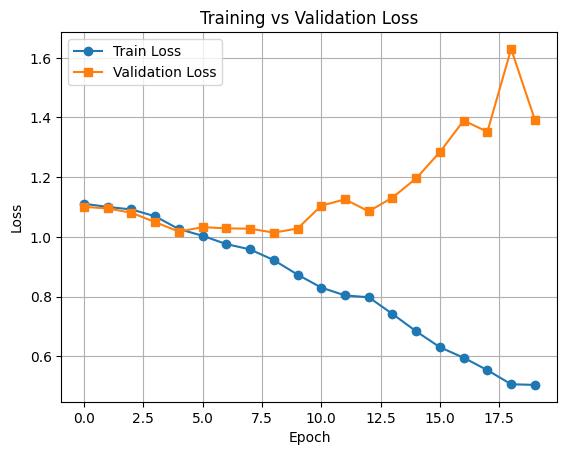

In [73]:
plt.plot(train_losses, marker='o', label='Train Loss')
plt.plot(val_losses, marker='s', label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

## Step 4 - Final test accuracy vs the Week-2 baseline

Evaluate ONCE on the test set. State your Week-2 baseline number and the improvement.

In [76]:
test_loss, test_acc = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

baseline = 0.42          # Replace with your actual Week 2 baseline
improvement = test_acc - baseline

print(f"Beat baseline by {improvement:.3f}")

Test Loss: 1.098
Test Accuracy: 0.400
Beat baseline by -0.020


## Step 5 - Confusion matrix

Collect predictions across the test set (move them to CPU before NumPy!), then display a labelled confusion matrix using `test_ds.classes`.

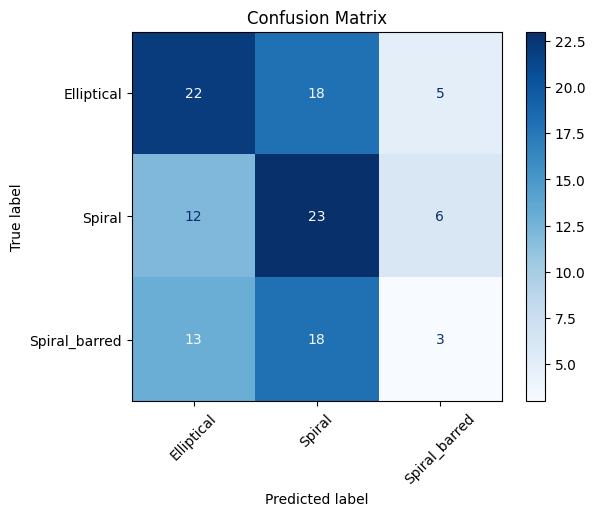

In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()


all_preds = []
all_labels = []


with torch.no_grad():

    for inputs, targets in test_loader:

        inputs = inputs.to(device)

        outputs = model(inputs)

        preds = outputs.argmax(dim=1).cpu()

        all_preds.append(preds)
        all_labels.append(targets)


y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_labels).numpy()


cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dataset.classes
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix")
plt.show()

## Step 6 - Per-class report + astrophysical reading

Print `classification_report`, then in a Markdown cell name the most-confused pair and link it to the astronomy (density waves / bars in [`04`](../04-spiral-structure-and-star-formation.md); lenticulars / mergers in [`08`](../08-lenticulars-mergers-and-evolution.md)).

In [78]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=dataset.classes
    )
)

               precision    recall  f1-score   support

   Elliptical       0.47      0.49      0.48        45
       Spiral       0.39      0.56      0.46        41
Spiral_barred       0.21      0.09      0.12        34

     accuracy                           0.40       120
    macro avg       0.36      0.38      0.35       120
 weighted avg       0.37      0.40      0.37       120



## Step 7 - Save and reload (round-trip check)

Save the `state_dict`, load it into a fresh `GalaxyCNN`, and assert the reloaded test accuracy matches the original.

In [79]:
torch.save(model.state_dict(), "galaxy_model.pth")

print("Model saved successfully!")

loaded = GalaxyCNN(num_classes=num_classes).to(device)

loaded.load_state_dict(
    torch.load("galaxy_model.pth", map_location=device)
)

loaded.eval()

_, acc2 = evaluate(
    loaded,
    test_loader,
    criterion,
    device
)

assert abs(acc2 - test_acc) < 1e-6

print(f"Round-trip verified! Accuracy = {acc2:.3f}")

Model saved successfully!
Round-trip verified! Accuracy = 0.400


## Reflection *(write 2-3 sentences each)*

1. What test accuracy did you reach, and by how much did the CNN beat the Week-2 baseline?
2. Did your curves show overfitting? How could you tell, and what would you try next?
3. Which two classes were confused most, and is that a model failure, a real physical ambiguity, or both?
4. Why is the save/reload round-trip check worth running rather than assuming it worked?

*(Replace this prompt with your answers.)*